# Model experiments: Feature Extraction vs LoRA vs QLoRA

This notebook keeps the model code visible in one place. Run `Preprocessing.ipynb` first so the processed Rotten Tomatoes files exist under `Data/processed/`.

Recommended flow:
1. Run setup cells.
2. Run Feature Extraction alone.
3. Run LoRA alone.
4. Run QLoRA alone if your CUDA + bitsandbytes setup works.
5. Run the final all-methods cell.

## 1. Imports and paths

In [1]:
from pathlib import Path
from dataclasses import dataclass
from inspect import signature
import importlib.util
import json
import random
import time
import traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "Output"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
RESULTS_DIR = OUTPUT_DIR / "results"
WEIGHTS_DIR = OUTPUT_DIR / "model_weights"

for path in [FIGURES_DIR, METRICS_DIR, RESULTS_DIR, WEIGHTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('c:/my/Projectes/DeepLearning/Bert-LORA-QLORA-imdb')

## 2. Experiment config

Start with a small `SAMPLE_SIZE` to test everything. Set `SAMPLE_SIZE = None` for the full Rotten Tomatoes splits.

In [2]:
MODEL_NAME = "bert-base-uncased"
RUN_LABEL = "notebook"
SEED = 42
MAX_LENGTH = 128
EPOCHS = 3
SAMPLE_SIZE = 5000  # Use None for full data.

COMMON_BATCH_SIZE = 2
COMMON_LR = 2e-5

LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

USE_FP16 = False
DEVICE_INFO = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
DEVICE_INFO

'NVIDIA GeForce RTX 3050 Laptop GPU'

## 3. Data loading and tokenization

In [3]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_processed_splits(sample_size: int | None = SAMPLE_SIZE, seed: int = SEED) -> DatasetDict:
    paths = {
        "train": DATA_DIR / "train.parquet",
        "validation": DATA_DIR / "validation.parquet",
        "test": DATA_DIR / "test.parquet",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Run Notebook/Preprocessing.ipynb first. Missing files: {missing}")

    frames = {}
    for split, path in paths.items():
        df = pd.read_parquet(path)[["text", "label"]].dropna()
        df["text"] = df["text"].astype(str)
        df["label"] = df["label"].astype(int)
        if sample_size:
            per_class = min(sample_size // 2, df["label"].value_counts().min())
            df = (
                df.groupby("label", group_keys=False)
                .sample(n=per_class, random_state=seed)
                .sample(frac=1, random_state=seed)
                .reset_index(drop=True)
            )
        frames[split] = Dataset.from_pandas(df, preserve_index=False)
    return DatasetDict(frames)


def tokenize_dataset(sample_size: int | None = SAMPLE_SIZE, max_length: int = MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    dataset = load_processed_splits(sample_size=sample_size)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=max_length)

    tokenized = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
    for split in tokenized:
        tokenized[split] = tokenized[split].rename_column("label", "labels")
    return tokenized, tokenizer


raw_preview = load_processed_splits(sample_size=5)
raw_preview

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
})

## 4. Metrics and saving helpers

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }


def count_parameters(model):
    if hasattr(model, "get_nb_trainable_parameters"):
        trainable, total = model.get_nb_trainable_parameters()
    else:
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total_parameters": int(total),
        "trainable_parameters": int(trainable),
        "trainable_percent": round((trainable / total) * 100, 4),
    }


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def peak_gpu_memory_mb():
    if not torch.cuda.is_available():
        return None
    return round(torch.cuda.max_memory_allocated() / (1024 ** 2), 2)


def save_metrics(run_name: str, payload: dict):
    metrics_path = METRICS_DIR / f"{run_name}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return metrics_path


SUMMARY_COLUMNS = [
    "run_name", "method", "seed", "status",
    "dataset_train_rows", "dataset_validation_rows", "dataset_test_rows",
    "sample_size", "epochs", "batch_size", "learning_rate", "max_length",
    "accuracy", "precision", "recall", "f1",
    "training_time_seconds", "peak_gpu_memory_mb", "model_dir",
    "total_parameters", "trainable_parameters", "trainable_percent", "error_file",
]


def append_summary(row: dict):
    summary_path = RESULTS_DIR / "summary_results.csv"
    new_row = pd.DataFrame([row]).reindex(columns=SUMMARY_COLUMNS)
    if summary_path.exists():
        existing = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
        new_row = pd.concat([existing, new_row], ignore_index=True)
    new_row.to_csv(summary_path, index=False)
    return summary_path

## 5. Shared Trainer runner

In [5]:
@dataclass
class RunConfig:
    method: str
    batch_size: int
    learning_rate: float
    epochs: float = EPOCHS
    seed: int = SEED
    max_length: int = MAX_LENGTH
    sample_size: int | None = SAMPLE_SIZE
    fp16: bool = USE_FP16


def training_args(config: RunConfig, run_dir: Path):
    args = {
        "output_dir": str(run_dir),
        "learning_rate": config.learning_rate,
        "per_device_train_batch_size": config.batch_size,
        "per_device_eval_batch_size": config.batch_size,
        "num_train_epochs": config.epochs,
        "weight_decay": 0.01,
        "logging_steps": 20,
        "save_strategy": "epoch",
        "save_total_limit": 1,
        "report_to": "none",
        "fp16": bool(config.fp16),
    }
    if "eval_strategy" in signature(TrainingArguments.__init__).parameters:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"
    return TrainingArguments(**args)


def train_and_evaluate(model, tokenizer, config: RunConfig):
    set_seed(config.seed)
    run_name = f"{RUN_LABEL}_{config.method}_seed_{config.seed}"
    run_dir = WEIGHTS_DIR / run_name
    tokenized, tokenizer = tokenize_dataset(sample_size=config.sample_size, max_length=config.max_length)
    params = count_parameters(model)
    print(f"{config.method} parameter counts:", params)

    trainer = Trainer(
        model=model,
        args=training_args(config, run_dir),
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    reset_gpu_memory()
    start = time.perf_counter()
    train_result = trainer.train()
    training_time = round(time.perf_counter() - start, 2)
    test_metrics = trainer.evaluate(tokenized["test"])

    final_dir = run_dir / "final"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))

    row = {
        "run_name": run_name,
        "method": config.method,
        "seed": config.seed,
        "status": "ok",
        "dataset_train_rows": len(tokenized["train"]),
        "dataset_validation_rows": len(tokenized["validation"]),
        "dataset_test_rows": len(tokenized["test"]),
        "sample_size": config.sample_size,
        "epochs": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "max_length": config.max_length,
        "accuracy": test_metrics.get("eval_accuracy"),
        "precision": test_metrics.get("eval_precision"),
        "recall": test_metrics.get("eval_recall"),
        "f1": test_metrics.get("eval_f1"),
        "training_time_seconds": training_time,
        "peak_gpu_memory_mb": peak_gpu_memory_mb(),
        "model_dir": str(final_dir),
        **params,
    }
    save_metrics(run_name, {"config": config.__dict__, "train": train_result.metrics, "test": test_metrics, "summary": row})
    append_summary(row)
    return row

## 6. Feature Extraction only

BERT is frozen. Only the classification head is trained.

In [6]:
def build_feature_extraction_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    for param in model.bert.parameters():
        param.requires_grad = False
    return model


def run_feature_extraction():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_feature_extraction_model()
    config = RunConfig(method="feature", batch_size=COMMON_BATCH_SIZE, learning_rate=COMMON_LR)
    return train_and_evaluate(model, tokenizer, config)


feature_result = run_feature_extraction()
pd.DataFrame([feature_result]).T

c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 1066/1066 [00:00<00:00, 21755.41 examples/s]


feature parameter counts: {'total_parameters': 109483778, 'trainable_parameters': 1538, 'trainable_percent': 0.0014}


  0%|          | 0/7500 [00:00<?, ?it/s]c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
  0%|          | 26/7500 [00:01<03:28, 35.79it/s]

{'loss': 0.7182, 'grad_norm': 3.968559741973877, 'learning_rate': 1.9946666666666667e-05, 'epoch': 0.01}


  1%|          | 46/7500 [00:01<02:52, 43.24it/s]

...

{'eval_loss': 0.6694584488868713, 'eval_accuracy': 0.5816135084427767, 'eval_precision': 0.5574636723910171, 'eval_recall': 0.7917448405253283, 'eval_f1': 0.6542635658914728, 'eval_runtime': 9.5562, 'eval_samples_per_second': 111.551, 'eval_steps_per_second': 55.775, 'epoch': 3.0}


100%|██████████| 7500/7500 [03:26<00:00, 36.38it/s]


{'train_runtime': 206.1806, 'train_samples_per_second': 72.752, 'train_steps_per_second': 36.376, 'train_loss': 0.6833706685384114, 'epoch': 3.0}


100%|██████████| 533/533 [00:09<00:00, 58.32it/s]


,0
run_name,notebook_feature_seed_42
method,feature
seed,42
status,ok
dataset_train_rows,5000
dataset_validation_rows,1066
dataset_test_rows,1066
sample_size,5000
epochs,3
batch_size,2


## 7. LoRA only

BERT is frozen and small LoRA adapters are trained on attention `query` and `value` modules.

In [7]:
def build_lora_model():
    from peft import LoraConfig, TaskType, get_peft_model

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return get_peft_model(model, lora_config)


def run_lora():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_lora_model()
    config = RunConfig(method="lora", batch_size=COMMON_BATCH_SIZE, learning_rate=COMMON_LR)
    return train_and_evaluate(model, tokenizer, config)


lora_result = run_lora()
pd.DataFrame([lora_result]).T

c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 1066/1066 [00:00<00:00, 21323.48 examples/s]


lora parameter counts: {'total_parameters': 110075140, 'trainable_parameters': 591362, 'trainable_percent': 0.5372}


  0%|          | 23/7500 [00:01<06:35, 18.90it/s]

{'loss': 0.6727, 'grad_norm': 3.7468554973602295, 'learning_rate': 1.9946666666666667e-05, 'epoch': 0.01}


  1%|          | 44/7500 [00:02<06:11, 20.06it/s]

...

{'eval_loss': 0.6052489876747131, 'eval_accuracy': 0.8386491557223265, 'eval_precision': 0.839924670433145, 'eval_recall': 0.8367729831144465, 'eval_f1': 0.8383458646616542, 'eval_runtime': 11.5839, 'eval_samples_per_second': 92.024, 'eval_steps_per_second': 46.012, 'epoch': 3.0}


100%|██████████| 7500/7500 [08:05<00:00, 15.45it/s]


{'train_runtime': 485.5069, 'train_samples_per_second': 30.896, 'train_steps_per_second': 15.448, 'train_loss': 0.6057878225008647, 'epoch': 3.0}


100%|██████████| 533/533 [00:10<00:00, 50.31it/s]


,0
run_name,notebook_lora_seed_42
method,lora
seed,42
status,ok
dataset_train_rows,5000
dataset_validation_rows,1066
dataset_test_rows,1066
sample_size,5000
epochs,3
batch_size,2


## 8. QLoRA only

This needs a working CUDA + bitsandbytes setup. If it fails on native Windows, run this cell on WSL2, Linux, Colab, or Kaggle.

In [8]:
def build_qlora_model():
    if not torch.cuda.is_available():
        raise RuntimeError("QLoRA requires CUDA.")
    if importlib.util.find_spec("bitsandbytes") is None:
        raise RuntimeError("bitsandbytes is not installed.")

    from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
    from transformers import BitsAndBytesConfig

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float32,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        quantization_config=quant_config,
    )
    model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return get_peft_model(model, lora_config)


def run_qlora():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_qlora_model()
    config = RunConfig(method="qlora", batch_size=COMMON_BATCH_SIZE, learning_rate=COMMON_LR)
    return train_and_evaluate(model, tokenizer, config)


try:
    qlora_result = run_qlora()
except Exception as exc:
    error_path = METRICS_DIR / f"{RUN_LABEL}_qlora_error_seed_{SEED}.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    qlora_result = {"run_name": f"{RUN_LABEL}_qlora_seed_{SEED}", "method": "qlora", "seed": SEED, "status": "failed", "error_file": str(error_path), "error": str(exc)}
    append_summary(qlora_result)
    print("QLoRA failed cleanly. Check:", error_path)

pd.DataFrame([qlora_result]).T

c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
`low_cpu_mem_usage` was None, now set to True since model is quantized.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 1066/1066 [00:00<00:00, 17095.39 examples/s]


qlora parameter counts: {'total_parameters': 110075140, 'trainable_parameters': 591362, 'trainable_percent': 0.5372}


  0%|          | 0/7500 [00:00<?, ?it/s]c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\_dynamo\eval_frame.py:600: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]
  0%|          | 20/7500 [00:03<29:05,  4.29it/s]

{'loss': 0.6984, 'grad_norm': 4.750257968902588, 'learning_rate': 1.9946666666666667e-05, 'epoch': 0.01}


  1%|          | 41/7500 [00:07<18:41,  6.65it/s]

...

{'eval_loss': 0.6036939024925232, 'eval_accuracy': 0.8302063789868668, 'eval_precision': 0.8320754716981132, 'eval_recall': 0.8273921200750469, 'eval_f1': 0.8297271872060207, 'eval_runtime': 23.528, 'eval_samples_per_second': 45.308, 'eval_steps_per_second': 22.654, 'epoch': 3.0}


100%|██████████| 7500/7500 [18:25<00:00,  6.79it/s]


{'train_runtime': 1105.2741, 'train_samples_per_second': 13.571, 'train_steps_per_second': 6.786, 'train_loss': 0.6085491321881612, 'epoch': 3.0}


100%|██████████| 533/533 [00:22<00:00, 23.51it/s]


,0
run_name,notebook_qlora_seed_42
method,qlora
seed,42
status,ok
dataset_train_rows,5000
dataset_validation_rows,1066
dataset_test_rows,1066
sample_size,5000
epochs,3
batch_size,2


## 9. Compare current results

In [9]:
summary_path = RESULTS_DIR / "summary_results.csv"
summary = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
summary.tail(10)

,run_name,method,seed,status,dataset_train_rows,dataset_validation_rows,dataset_test_rows,sample_size,epochs,batch_size,...,precision,recall,f1,training_time_seconds,peak_gpu_memory_mb,model_dir,total_parameters,trainable_parameters,trainable_percent,error_file
15,notebook_qlora_seed_42,qlora,42,ok,1000.0,1000.0,1000.0,1000.0,3.00,8.0,...,0.609195,0.424000,0.500000,71.16,284.74,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109780228.0,296450.0,0.2700,NaN
16,notebook_feature_seed_42,feature,42,ok,1000.0,1000.0,1000.0,1000.0,3.00,16.0,...,0.537764,0.712000,0.612737,20.14,591.55,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,NaN
17,notebook_lora_seed_42,lora,42,ok,1000.0,1000.0,1000.0,1000.0,3.00,8.0,...,0.539179,0.578000,0.557915,39.69,940.09,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109780228.0,296450.0,0.2700,NaN
18,notebook_qlora_seed_42,qlora,42,ok,1000.0,1000.0,1000.0,1000.0,3.00,8.0,...,0.609195,0.424000,0.500000,73.02,281.49,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109780228.0,296450.0,0.2700,NaN
19,feature_seed_42,feature,42,ok,8.0,8.0,8.0,8.0,0.01,2.0,...,0.571429,1.000000,0.727273,3.21,437.51,C:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,NaN
20,lora_seed_42,lora,42,ok,8.0,8.0,8.0,8.0,0.01,2.0,...,0.571429,1.000000,0.727273,1.45,467.15,C:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109780228.0,296450.0,0.2700,NaN
21,qlora_seed_42,qlora,42,ok,8.0,8.0,8.0,8.0,0.01,2.0,...,0.500000,1.000000,0.666667,1.31,176.22,C:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109780228.0,296450.0,0.2700,NaN
22,notebook_feature_seed_42,feature,42,ok,5000.0,1066.0,1066.0,5000.0,3.00,2.0,...,0.552356,0.791745,0.650732,207.36,443.41,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,NaN
23,notebook_lora_seed_42,lora,42,ok,5000.0,1066.0,1066.0,5000.0,3.00,2.0,...,0.834601,0.823640,0.829084,485.72,565.33,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
24,notebook_qlora_seed_42,qlora,42,ok,5000.0,1066.0,1066.0,5000.0,3.00,2.0,...,0.836576,0.806754,0.821394,1105.50,200.02,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN


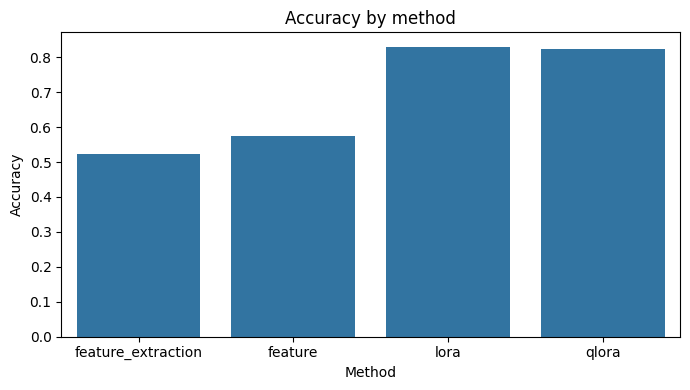

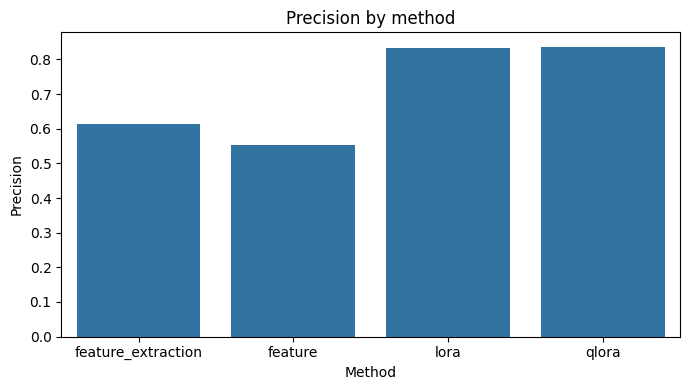

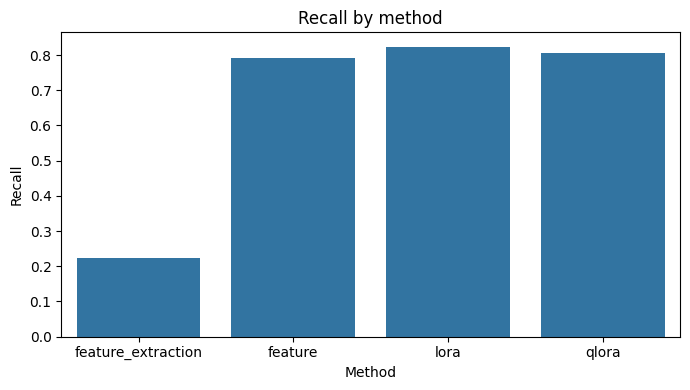

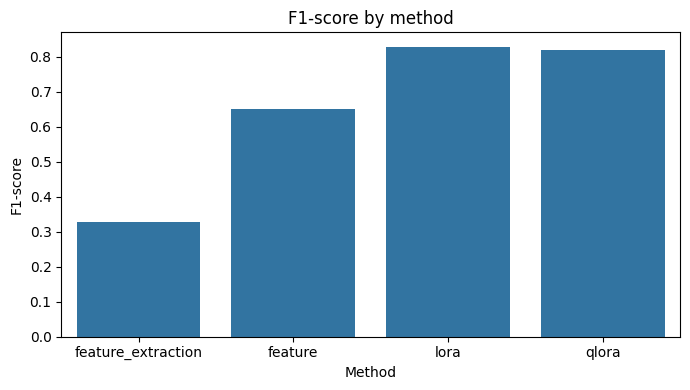

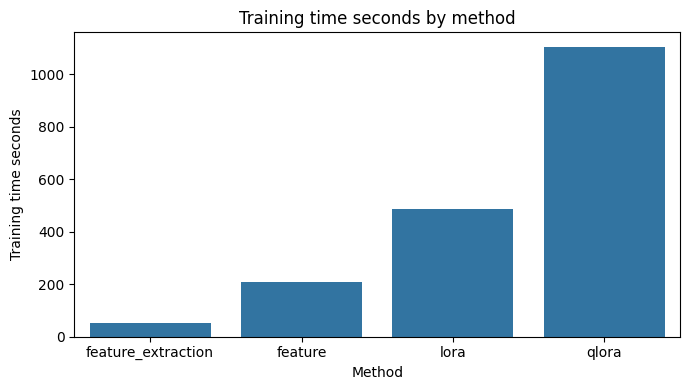

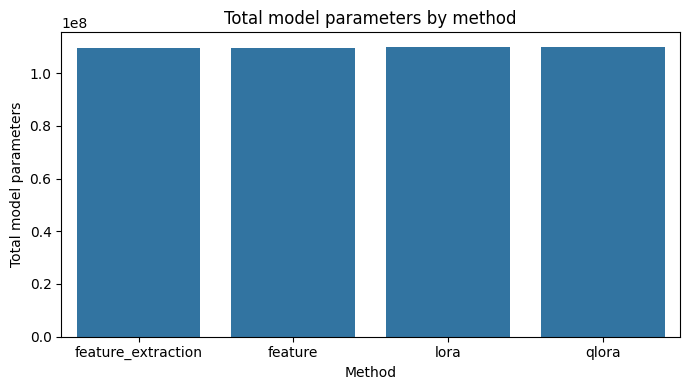

In [10]:
def plot_metric(summary: pd.DataFrame, metric: str, ylabel: str):
    ok = summary[summary.get("status", "ok").fillna("ok").eq("ok")].dropna(subset=[metric]).copy()
    if ok.empty:
        print(f"No values to plot for {metric}")
        return None
    latest = ok.groupby("method", as_index=False).tail(1)
    plt.figure(figsize=(7, 4))
    sns.barplot(data=latest, x="method", y=metric)
    plt.title(f"{ylabel} by method")
    plt.xlabel("Method")
    plt.ylabel(ylabel)
    plt.tight_layout()
    path = FIGURES_DIR / f"notebook_{metric}_comparison.png"
    plt.savefig(path, dpi=180)
    plt.show()
    return path


for metric, label in [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-score"),
    ("training_time_seconds", "Training time seconds"),
    ("total_parameters", "Total model parameters"),
]:
    if metric in summary.columns:
        plot_metric(summary, metric, label)

## 10. Run everything together

This final cell runs Feature Extraction, LoRA, then QLoRA in one pass. Keep `SAMPLE_SIZE` small until the flow is stable, then set it to `None` and increase `EPOCHS`.

In [ ]:
all_results = []

for name, runner in [
    ("feature_extraction", run_feature_extraction),
    ("lora", run_lora),
    ("qlora", run_qlora),
]:
    print(f"\n===== Running {name} =====")
    try:
        result = runner()
    except Exception as exc:
        error_path = METRICS_DIR / f"{RUN_LABEL}_{name}_all_error_seed_{SEED}.txt"
        error_path.write_text(traceback.format_exc(), encoding="utf-8")
        result = {"run_name": f"{RUN_LABEL}_{name}_seed_{SEED}", "method": name, "seed": SEED, "status": "failed", "error_file": str(error_path), "error": str(exc)}
        append_summary(result)
        print(f"{name} failed cleanly. Check: {error_path}")
    all_results.append(result)

pd.DataFrame(all_results)


===== Running feature_extraction =====


c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 1066/1066 [00:00<00:00, 16397.82 examples/s]


feature parameter counts: {'total_parameters': 109483778, 'trainable_parameters': 1538, 'trainable_percent': 0.0014}


  0%|          | 28/7500 [00:00<03:19, 37.50it/s]

{'loss': 0.6594, 'grad_norm': 5.577267646789551, 'learning_rate': 1.9946666666666667e-05, 'epoch': 0.01}


...

 61%|██████    | 4584/7500 [02:03<01:15, 38.80it/s]

{'loss': 0.6768, 'grad_norm': 13.32249927520752, 'learning_rate': 7.786666666666666e-06, 'epoch': 1.83}


 61%|██████▏   | 4607/7500 [02:03<01:12, 40.12it/s]

{'loss': 0.6491, 'grad_norm': 10.284507751464844, 'learning_rate': 7.733333333333334e-06, 'epoch': 1.84}


 61%|██████▏   | 4612/7500 [02:03<01:11, 40.39it/s]